##***Feature Engineering***

In [ ]:
df['churn_flag'] = df['churn'].map({'no': 0, 'yes': 1})

In [ ]:
#Avg duration of calls for churned customers
df['avg_day_call_duration'] = df['total_day_minutes'] / df['total_day_calls']
df['avg_eve_call_duration'] = df['total_eve_minutes'] / df['total_eve_calls']
df['avg_night_call_duration'] = df['total_night_minutes'] / df['total_night_calls']
df['avg_intl_call_duration'] = df['total_intl_minutes'] / df['total_intl_calls']

In [ ]:
df['total_calls'] = df['total_day_calls'] + df['total_eve_calls'] + df['total_night_calls'] + df['total_intl_calls']

In [ ]:
df['avg_call_duration'] = df['total_usage']/df['total_calls']

In [ ]:
df['day_usage_share'] = df['total_day_minutes'] / df['total_usage']
df['eve_usage_share'] = df['total_eve_minutes'] / df['total_usage']
df['night_usage_share'] = df['total_night_minutes'] / df['total_usage']
df['intl_usage_share'] = df['total_intl_minutes'] / df['total_usage']

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# New engineered features
df['service_calls_per_month_proxy'] = df['number_customer_service_calls'] / (df['account_length'] + 1)

df['intl_charge_per_call'] = df['total_intl_charge'] / (df['total_intl_calls'] + 1)
df['intl_mins_per_call'] = df['total_intl_minutes'] / (df['total_intl_calls'] + 1)

df['high_service_issue_flag'] = (df['number_customer_service_calls'] >= 4).astype(int)

df['high_value_customer_flag'] = (df['total_charges'] > df['total_charges'].quantile(0.75)).astype(int)

df['high_value_dissatisfied_flag'] = (
    (df['total_charges'] > df['total_charges'].quantile(0.75)) &
    (df['number_customer_service_calls'] >= 3)
).astype(int)

df['is_day_heavy_user'] = (df['day_usage_share'] > 0.45).astype(int)
df['is_intl_heavy_user'] = (df['intl_usage_share'] > df['intl_usage_share'].quantile(0.75)).astype(int)

df['charge_per_minute'] = df['total_charges'] / (df['total_usage'] + 1)
df['calls_per_minute'] = df['total_calls'] / (df['total_usage'] + 1)

In [ ]:
#dropping redundant features
df.drop(columns = ['total_day_charge', 'total_eve_charge', 'total_night_charge', 'total_intl_charge'], inplace = True)

I retained usage-based features instead of their charge counterparts because charge variables were deterministic transformations of minutes, leading to perfect multicollinearity and redundant model input.

### ***Outlier Treatment***

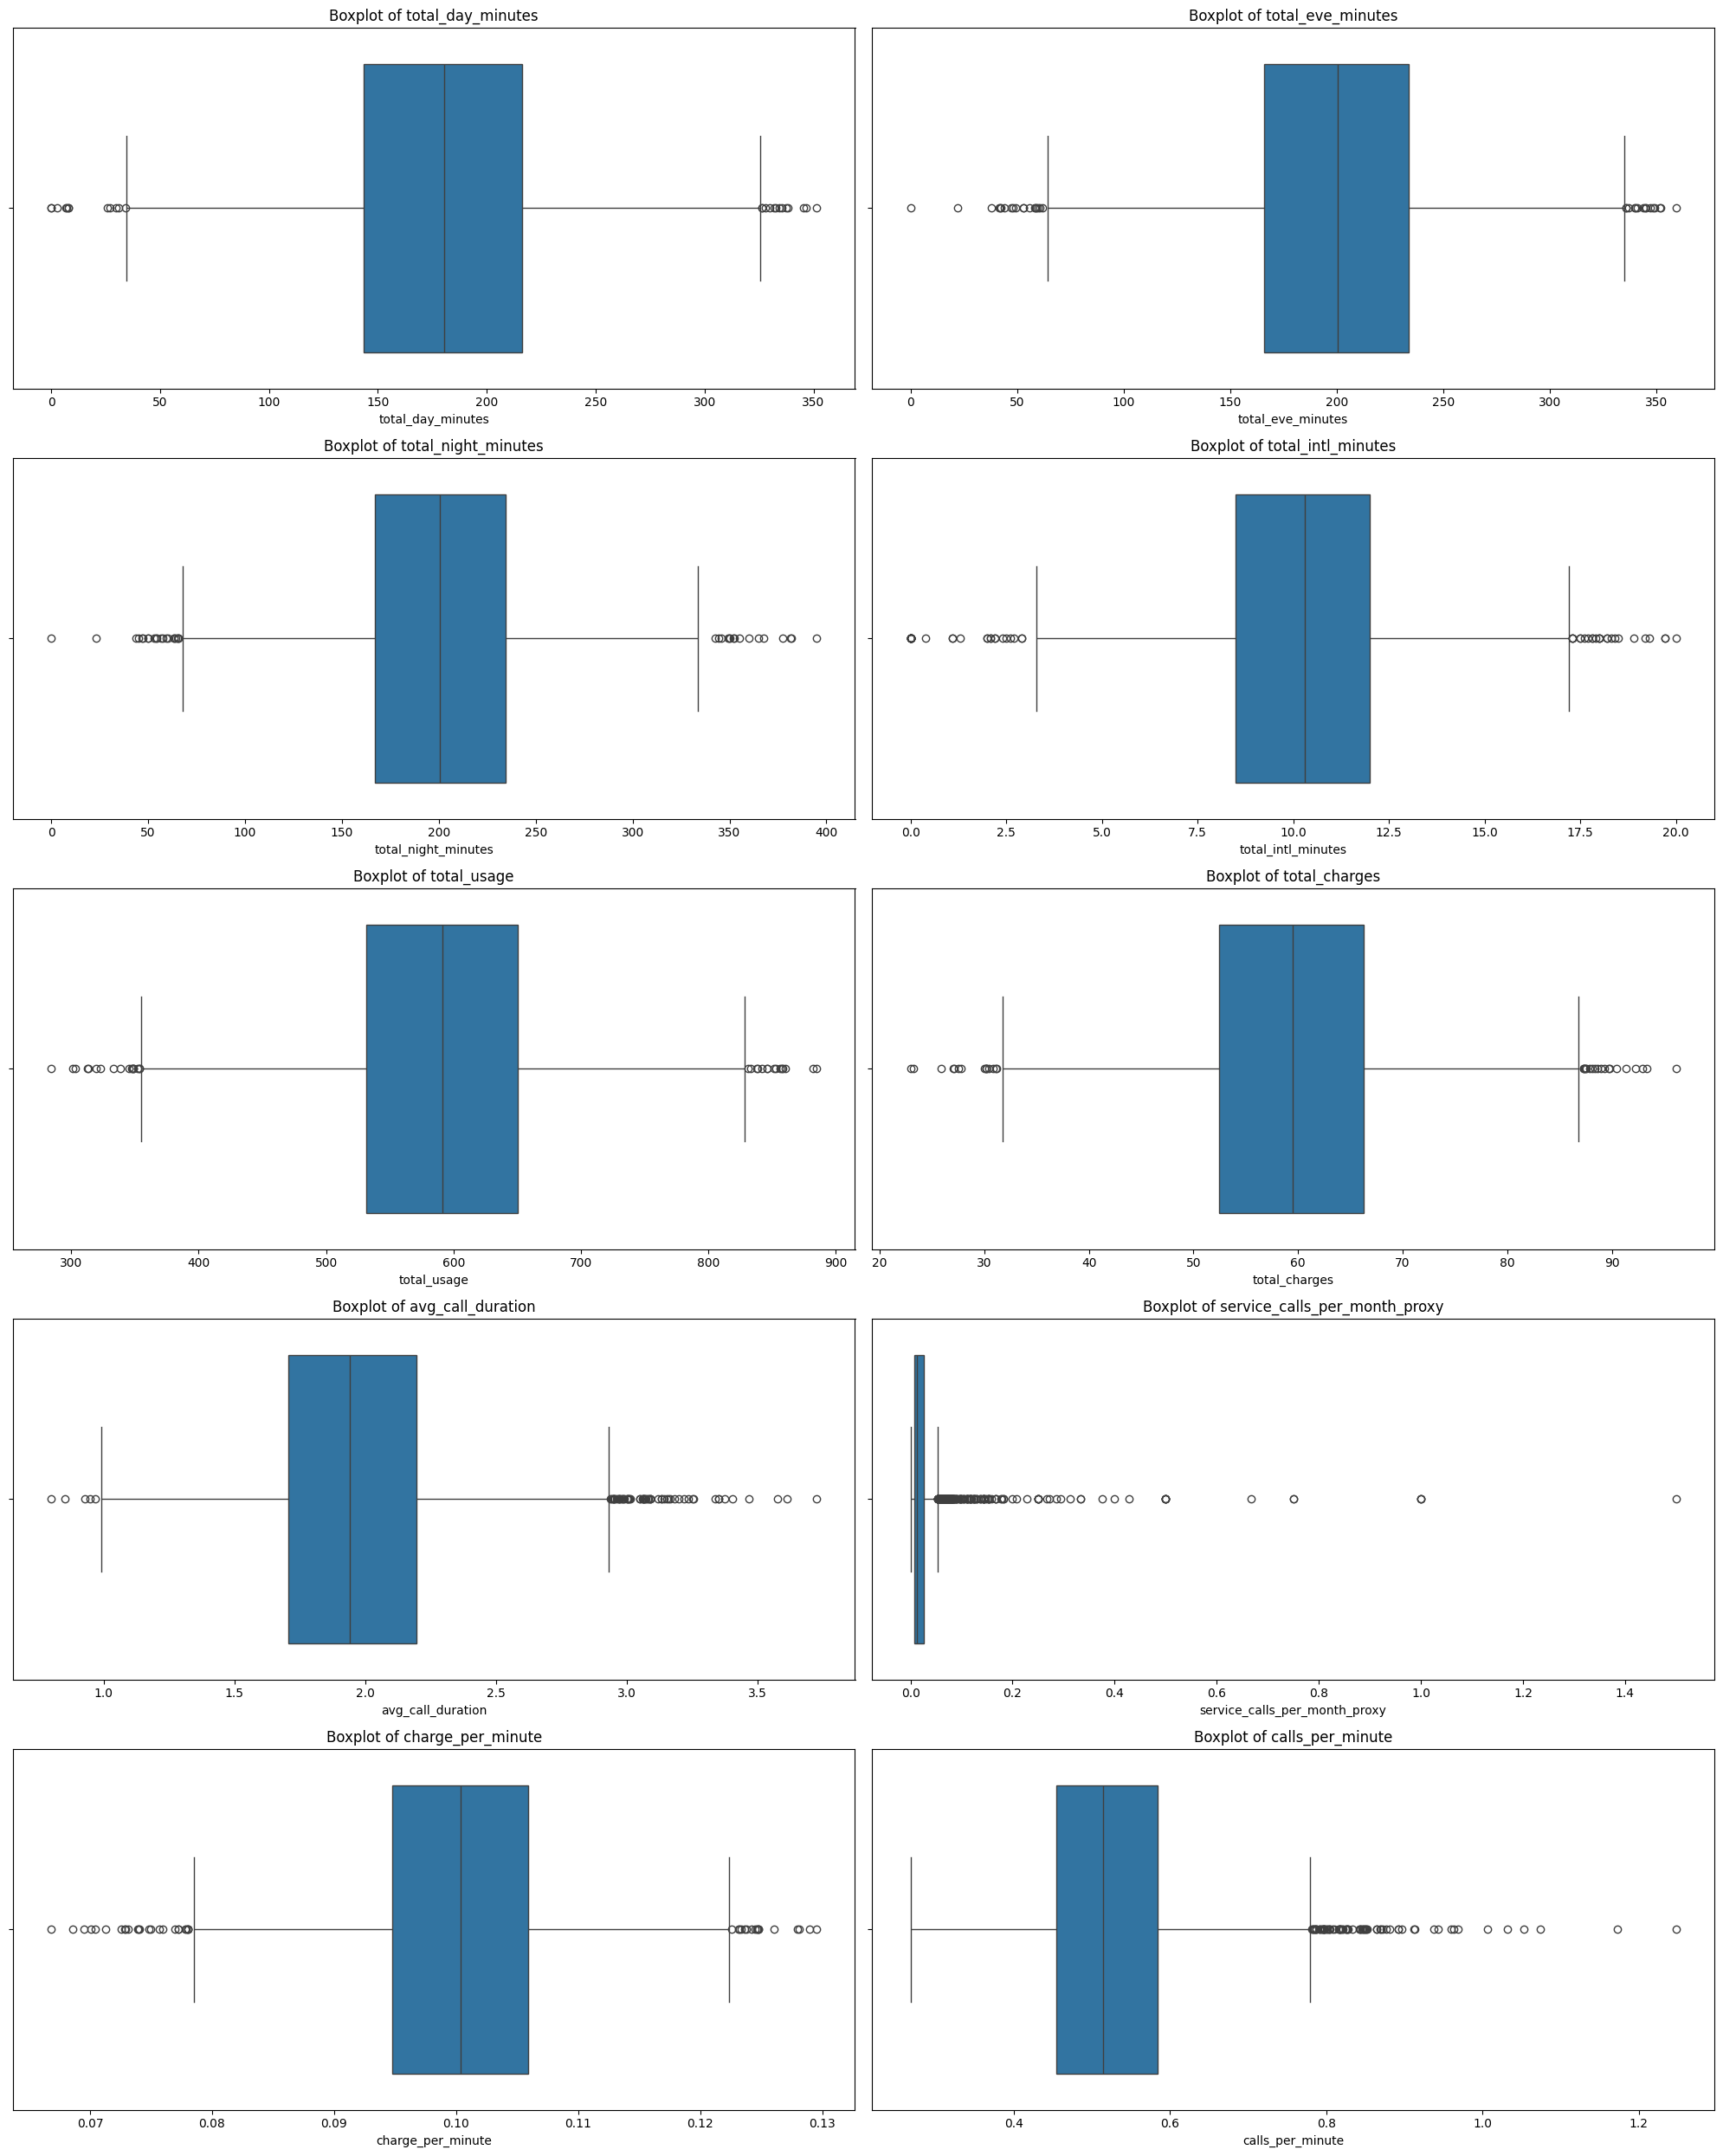

In [ ]:
# Handling Outliers & Outlier treatments
priority_outlier_cols = [
    'total_day_minutes',
    'total_eve_minutes',
    'total_night_minutes',
    'total_intl_minutes',
    'total_usage',
    'total_charges',
    'avg_call_duration',
    'service_calls_per_month_proxy',
    'charge_per_minute',
    'calls_per_minute'
]

plt.figure(figsize=(20, 25))

for i, col in enumerate(priority_outlier_cols, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

outlier_summary = []

for col in priority_outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_percent = round((outlier_count / len(df)) * 100, 2)

    outlier_summary.append({
        'feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': outlier_count,
        'outlier_percent': outlier_percent
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(by='outlier_percent', ascending=False)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
7,service_calls_per_month_proxy,0.01,0.03,0.02,-0.02,0.05,268,6.31
9,calls_per_minute,0.45,0.58,0.13,0.26,0.78,70,1.65
6,avg_call_duration,1.71,2.20,0.49,0.97,2.93,63,1.48
3,total_intl_minutes,8.50,12.00,3.50,3.25,17.25,62,1.46
8,charge_per_minute,0.09,0.11,0.01,0.08,0.12,42,0.99
2,total_night_minutes,167.22,234.70,67.47,66.01,335.91,37,0.87
5,total_charges,52.43,66.30,13.87,31.63,87.10,34,0.80
1,total_eve_minutes,165.92,233.78,67.85,64.15,335.55,34,0.80
4,total_usage,531.83,650.50,118.67,353.81,828.51,32,0.75
0,total_day_minutes,143.33,216.20,72.87,34.01,325.51,25,0.59


In [ ]:
def iqr_winsorize(df, columns):
    df = df.copy()
    cap_summary = []

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        original_min = df[col].min()
        original_max = df[col].max()

        df[col] = df[col].clip(lower, upper)

        new_min = df[col].min()
        new_max = df[col].max()

        cap_summary.append({
            'feature': col,
            'lower_cap': round(lower, 4),
            'upper_cap': round(upper, 4),
            'original_min': round(original_min, 4),
            'original_max': round(original_max, 4),
            'new_min': round(new_min, 4),
            'new_max': round(new_max, 4)
        })

    cap_summary_df = pd.DataFrame(cap_summary)
    return df, cap_summary_df

In [ ]:
cap_cols = [
    'service_calls_per_month_proxy',
    'calls_per_minute',
    'avg_call_duration',
    'total_intl_minutes',
    'charge_per_minute'
]

df, cap_summary_df = iqr_winsorize(df, cap_cols)

cap_summary_df

,feature,lower_cap,upper_cap,original_min,original_max,new_min,new_max
0,service_calls_per_month_proxy,-0.0215,0.0536,0.0000,1.5000,0.0000,0.0536
1,calls_per_minute,0.2592,0.7802,0.2680,1.2478,0.2680,0.7802
2,avg_call_duration,0.9717,2.9317,0.7986,3.7263,0.9717,2.9317
3,total_intl_minutes,3.2500,17.2500,0.0000,20.0000,3.2500,17.2500
4,charge_per_minute,0.0781,0.1225,0.0668,0.1296,0.0781,0.1225


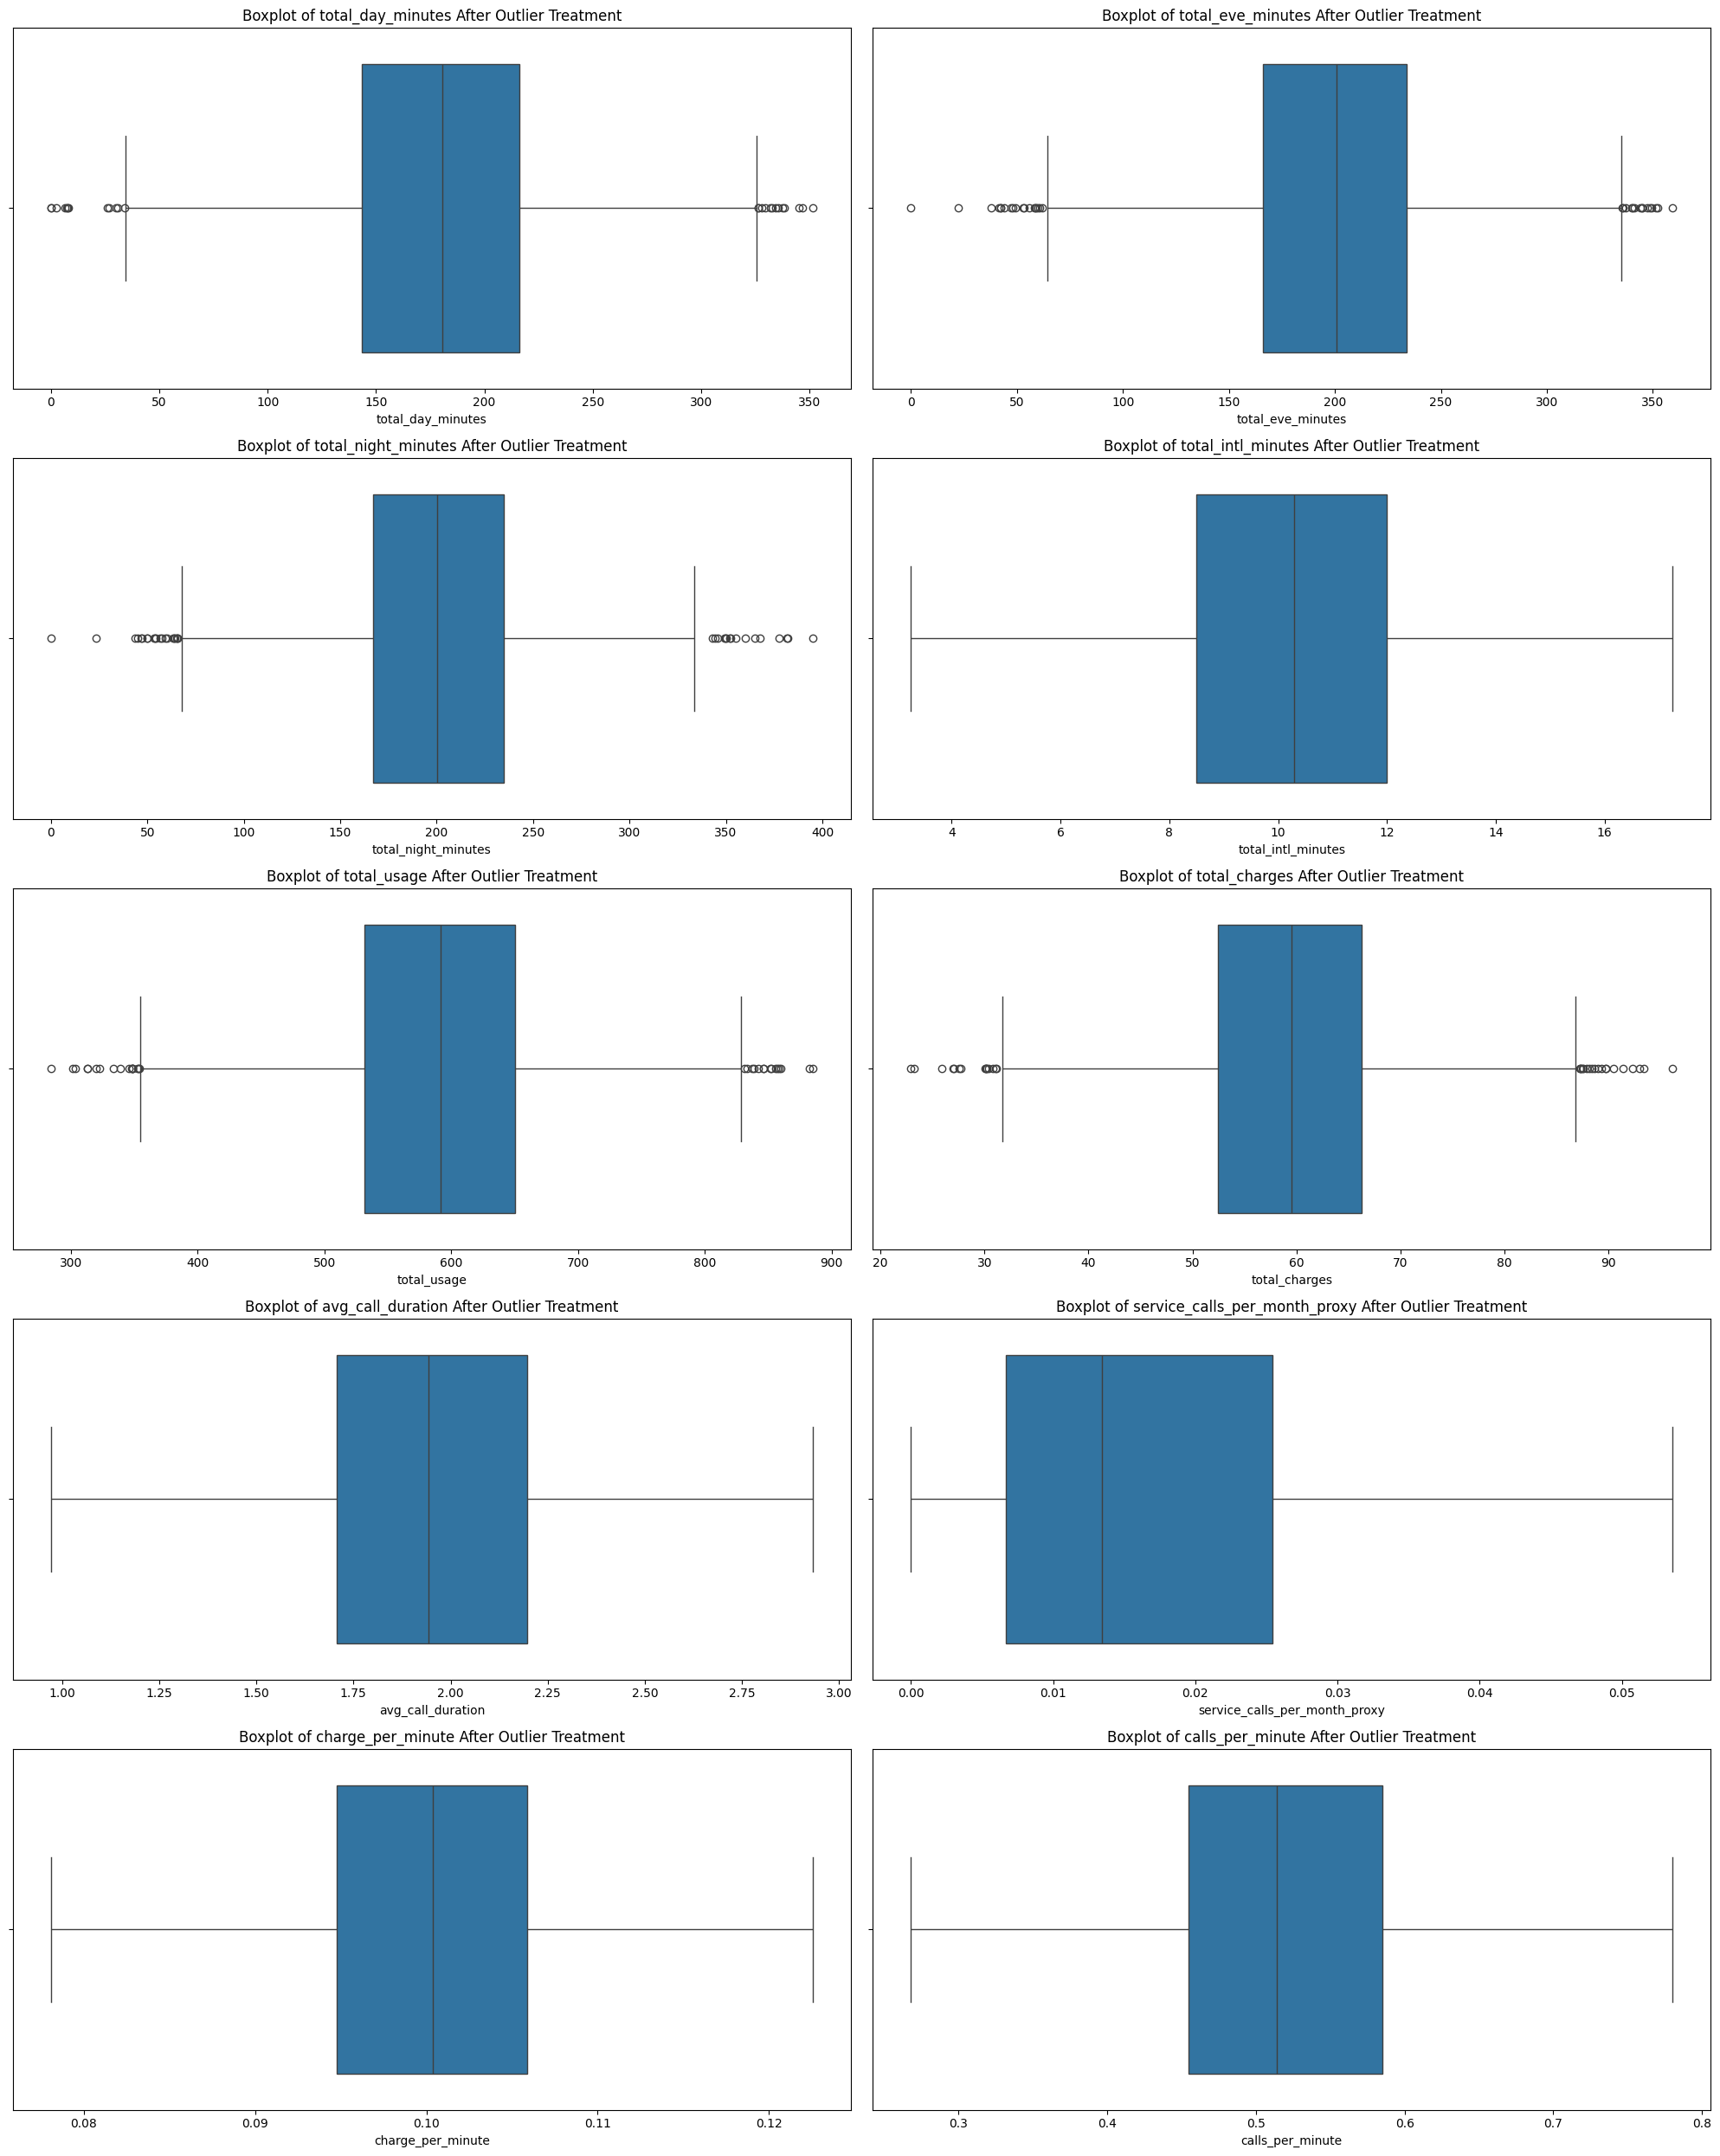

In [ ]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(priority_outlier_cols, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} After Outlier Treatment')

plt.tight_layout()
plt.show()

In [ ]:
# restore from original if available
df['total_intl_minutes'] = dataset['total_intl_minutes'].copy()

# apply upper-only cap
df['total_intl_minutes'] = df['total_intl_minutes'].clip(upper=17.25)

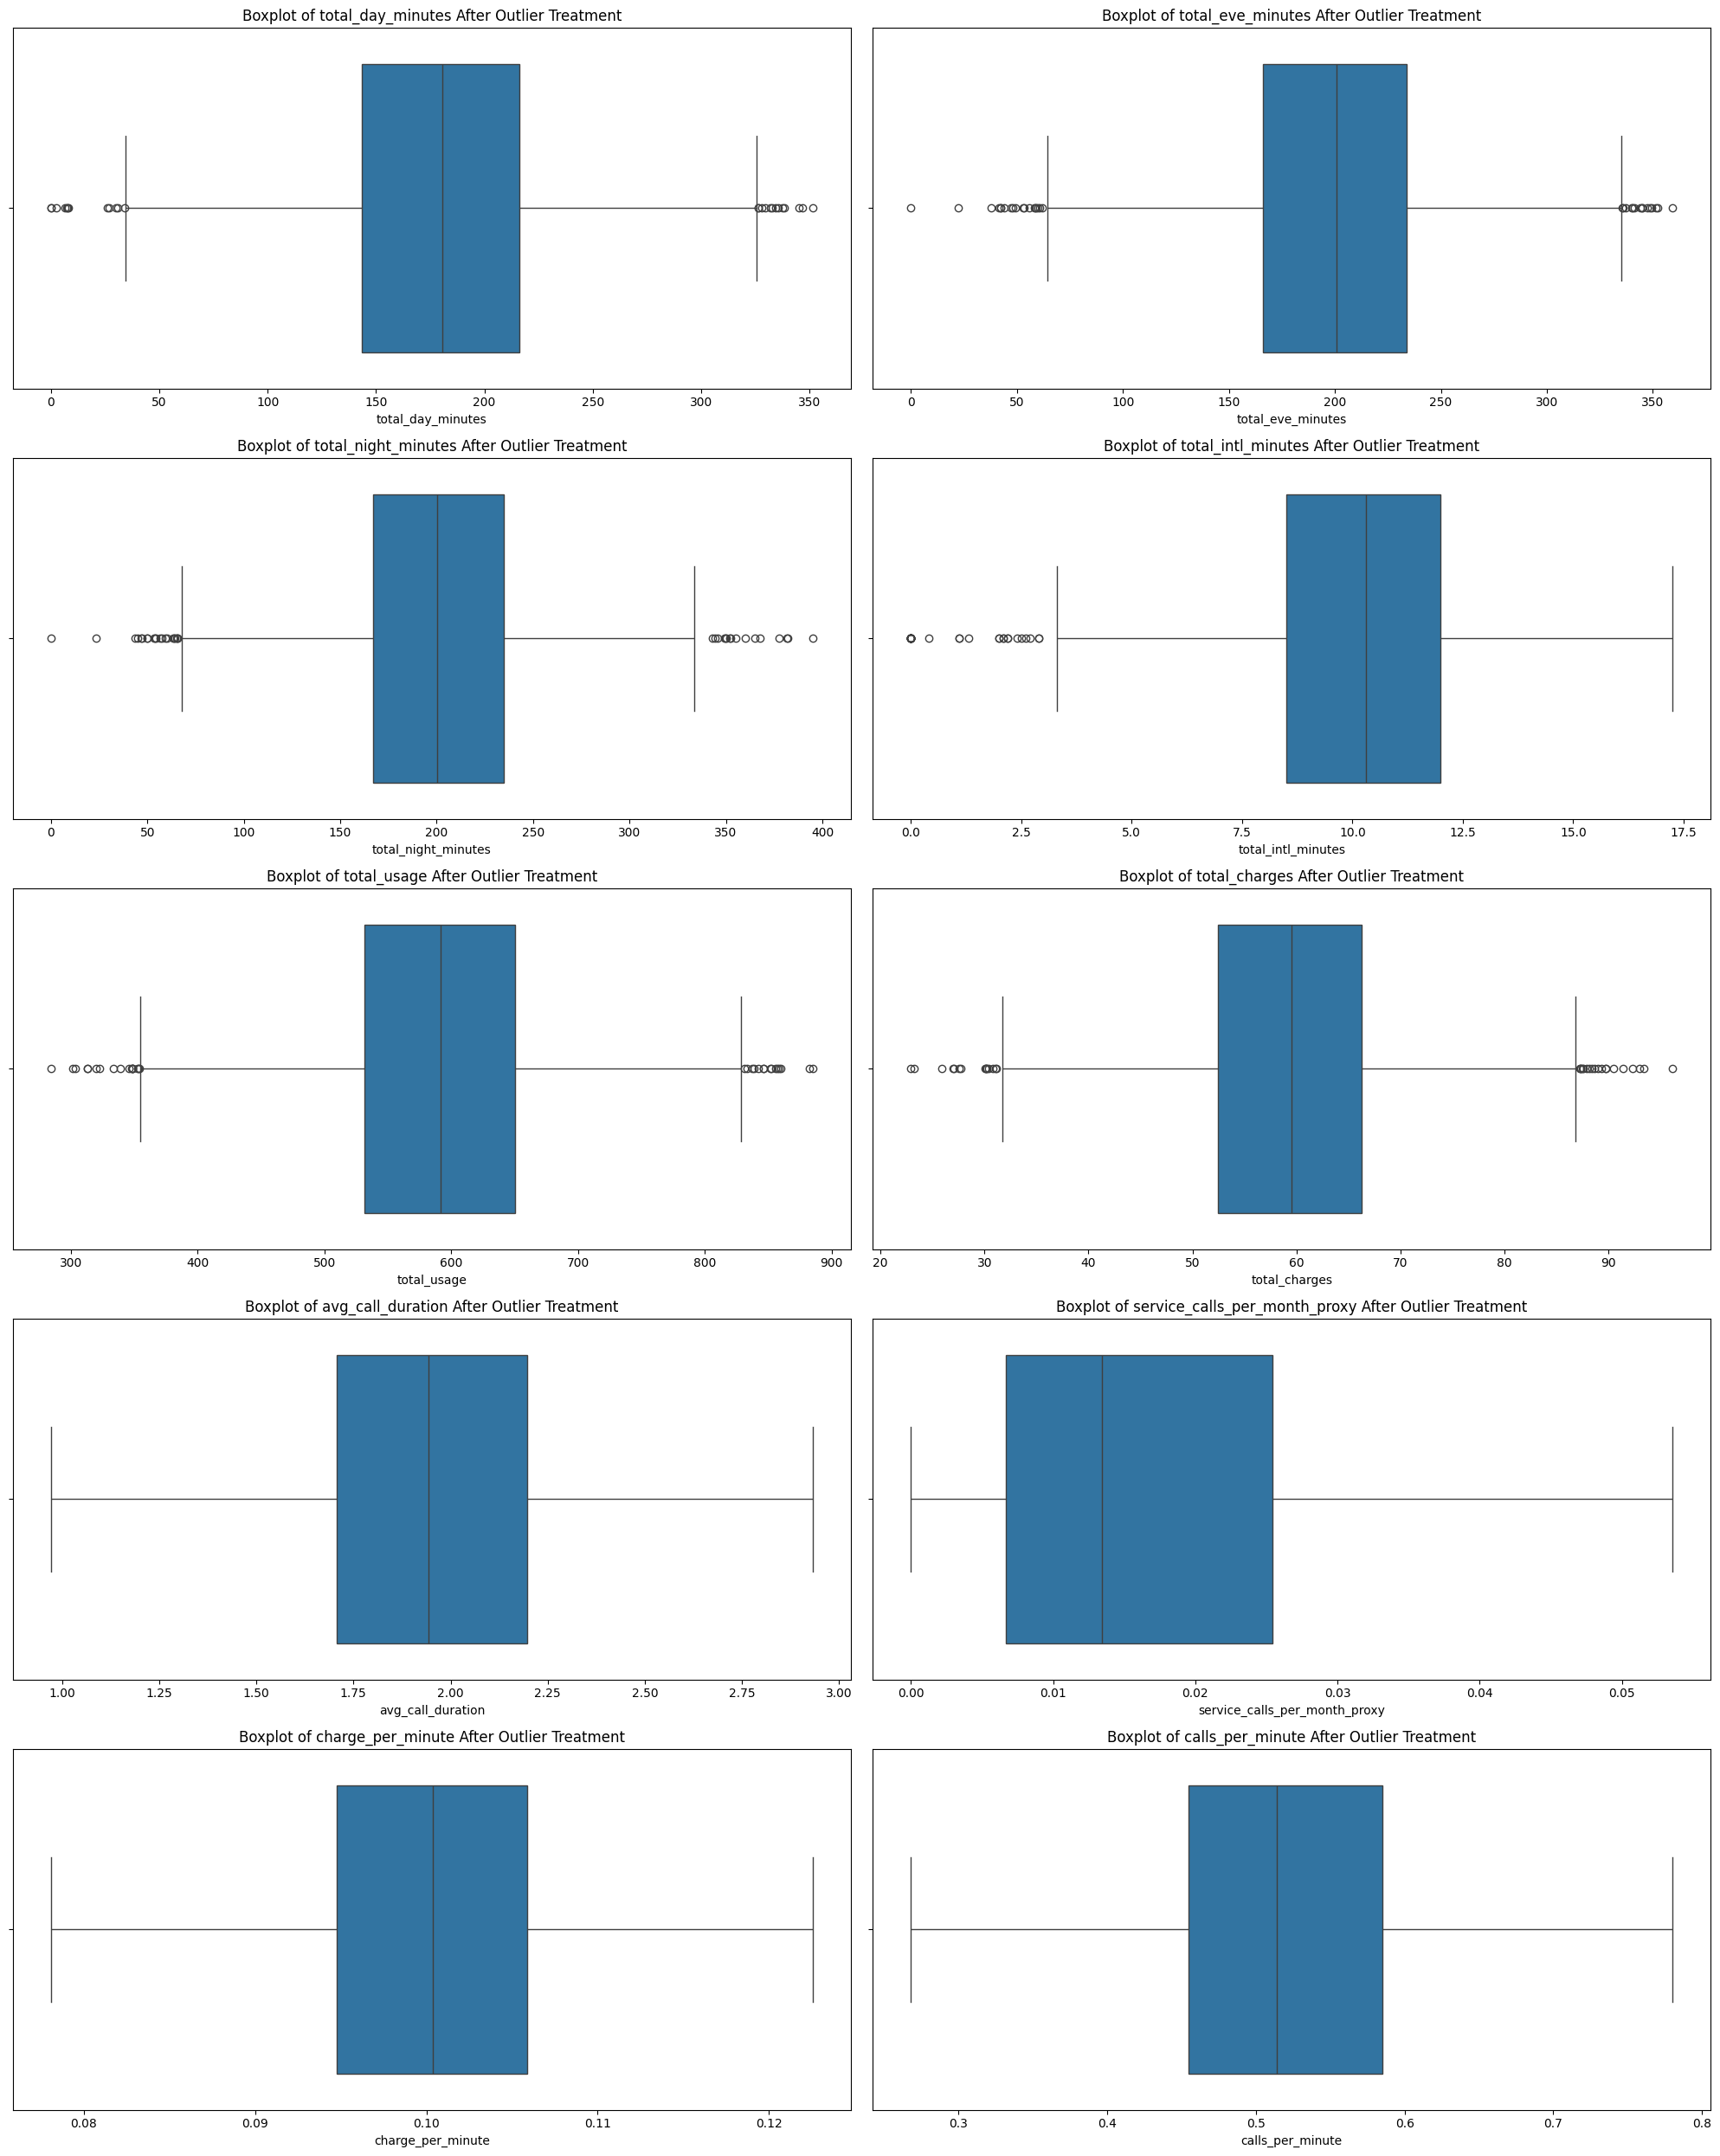

In [ ]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(priority_outlier_cols, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} After Outlier Treatment')

plt.tight_layout()
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

**Outlier Inspection and Treatment**

Outliers were inspected using boxplots and an IQR-based summary across selected high-variance numerical features.

The analysis showed that most features had low outlier percentages, suggesting that the dataset did not suffer from a major outlier problem. Since this is a customer behavior dataset, many extreme values were interpreted as genuine high-usage or high-friction customer patterns rather than data quality issues.

Therefore, aggressive row deletion was avoided.

Instead, a light outlier treatment strategy was applied using IQR-based winsorization (capping) on selected ratio-based and behavior-derived features:

service_calls_per_month_proxy
calls_per_minute
avg_call_duration
charge_per_minute

Additionally, total_intl_minutes was lightly controlled on the upper side to reduce the influence of extreme international usage values while preserving low-usage customer behavior.

This approach improved feature stability while retaining important churn-related business signals.

###***Data Cleaning***

In [ ]:
#Dropping the target label column as we have already created a churn_flag column
df.drop(['churn'], axis=1, inplace = True)

In [ ]:
#Dropping bucket columns as they have been derived from the original features and may lead to redundancy
df.drop(['high_usage', 'account_length_group', 'service_call_group', 'usage_group'], axis=1, inplace = True)

#Dropping redundant average duration columns
df.drop(['avg_day_call_duration', 'avg_eve_call_duration', 'avg_night_call_duration', 'avg_intl_call_duration'], axis=1, inplace=True)

#Dropping one of the ratio duplicates
df.drop(['charge_per_unit'], axis=1, inplace=True)


In [ ]:
# To see the column names that are 'object' type
df.select_dtypes(include=['object']).columns

Index(['state', 'area_code', 'international_plan', 'voice_mail_plan'], dtype='object')

###**Categorical Encoding for churn prediction**

In [ ]:
categorical_cols = [
    'state',
    'area_code',
    'international_plan',
    'voice_mail_plan',
    'customer_segment'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)